In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('../data/delivery_data.csv')

# First look of the data
# total we have 144867 raws, solid amount of data!!!
# 24 pieces of information, good
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())

Shape: (144867, 24)

Columns:
 ['data', 'trip_creation_time', 'route_schedule_uuid', 'route_type', 'trip_uuid', 'source_center', 'source_name', 'destination_center', 'destination_name', 'od_start_time', 'od_end_time', 'start_scan_to_end_scan', 'is_cutoff', 'cutoff_factor', 'cutoff_timestamp', 'actual_distance_to_destination', 'actual_time', 'osrm_time', 'osrm_distance', 'factor', 'segment_actual_time', 'segment_osrm_time', 'segment_osrm_distance', 'segment_factor']


In [ ]:
# Checked data types and missing values
print("Data Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())

# Issue 
# 1. trip_creation_time, od_start_time, od_end_time, cutoff_timestamp are stored as strings but they should be datetime.
# Missing values  
# Only source_name (293 missing) and destination_name (261 missing) have gaps.
# These are just the human-readable names of facilities. We have source_center and destination_center (the facility codes) which have zero missing values.

Data Types:
data                                  str
trip_creation_time                    str
route_schedule_uuid                   str
route_type                            str
trip_uuid                             str
source_center                         str
source_name                           str
destination_center                    str
destination_name                      str
od_start_time                         str
od_end_time                           str
start_scan_to_end_scan            float64
is_cutoff                            bool
cutoff_factor                       int64
cutoff_timestamp                      str
actual_distance_to_destination    float64
actual_time                       float64
osrm_time                         float64
osrm_distance                     float64
factor                            float64
segment_actual_time               float64
segment_osrm_time                 float64
segment_osrm_distance             float64
segment_factor        

In [ ]:
# How many FTL vs Carting trips?
# we have 99,600 FTL and 45,207 carting , ratio is around 2:1
print("Route Type Distribution:")
print(df['route_type'].value_counts())
print("\n")

# Key numeric columns statistics
# Findings :- The gap between actual and osrm time is massive — this is exactly the problem we're solving.
print("Key Statistics:")
print(df[['actual_time', 'osrm_time', 'actual_distance_to_destination', 'segment_factor']].describe())

Route Type Distribution:
route_type
FTL        99660
Carting    45207
Name: count, dtype: int64


Key Statistics:
         actual_time      osrm_time  actual_distance_to_destination  \
count  144867.000000  144867.000000                   144867.000000   
mean      416.927527     213.868272                      234.073372   
std       598.103621     308.011085                      344.990009   
min         9.000000       6.000000                        9.000045   
25%        51.000000      27.000000                       23.355874   
50%       132.000000      64.000000                       66.126571   
75%       513.000000     257.000000                      286.708875   
max      4532.000000    1686.000000                     1927.447705   

       segment_factor  
count   144867.000000  
mean         2.218368  
std          4.847530  
min        -23.444444  
25%          1.347826  
50%          1.684211  
75%          2.250000  
max        574.250000  


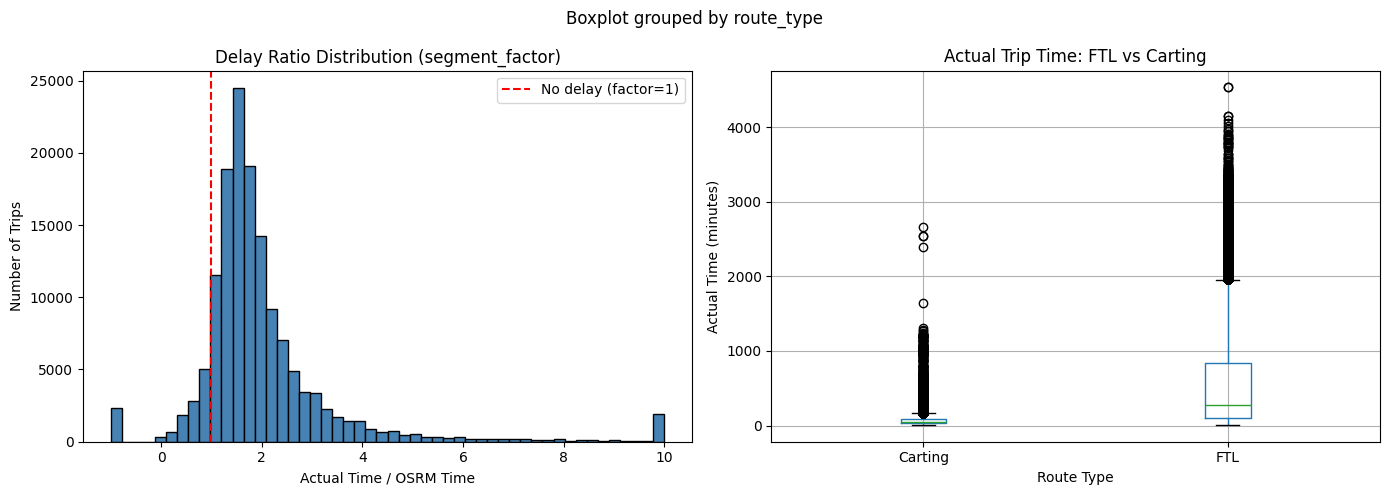

Plot saved to outputs folder!


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of segment_factor (delay ratio)
axes[0].hist(df['segment_factor'].clip(-1, 10), bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Delay Ratio Distribution (segment_factor)')
axes[0].set_xlabel('Actual Time / OSRM Time')
axes[0].set_ylabel('Number of Trips')
axes[0].axvline(x=1, color='red', linestyle='--', label='No delay (factor=1)')
axes[0].legend()

# FTL vs Carting actual time comparison
df.boxplot(column='actual_time', by='route_type', ax=axes[1])
axes[1].set_title('Actual Trip Time: FTL vs Carting')
axes[1].set_xlabel('Route Type')
axes[1].set_ylabel('Actual Time (minutes)')

plt.tight_layout()
plt.savefig('../outputs/delay_distribution.png')
plt.show()
print("Plot saved to outputs folder!")

# red line shows no delay in 1st plot
# almost all the trips lie to the right of the red line means nearly every trip has delays
# peak is around 1.5-2x delay - so on an average trip takes 50-100% longer than predicted!!

# Carting trips are short and clustered near 0 — quick local deliveries
# FTL trips have a much wider range — long hauls with huge variation
# Both have extreme outliers (dots at top) — those are the problem trips we need to catch



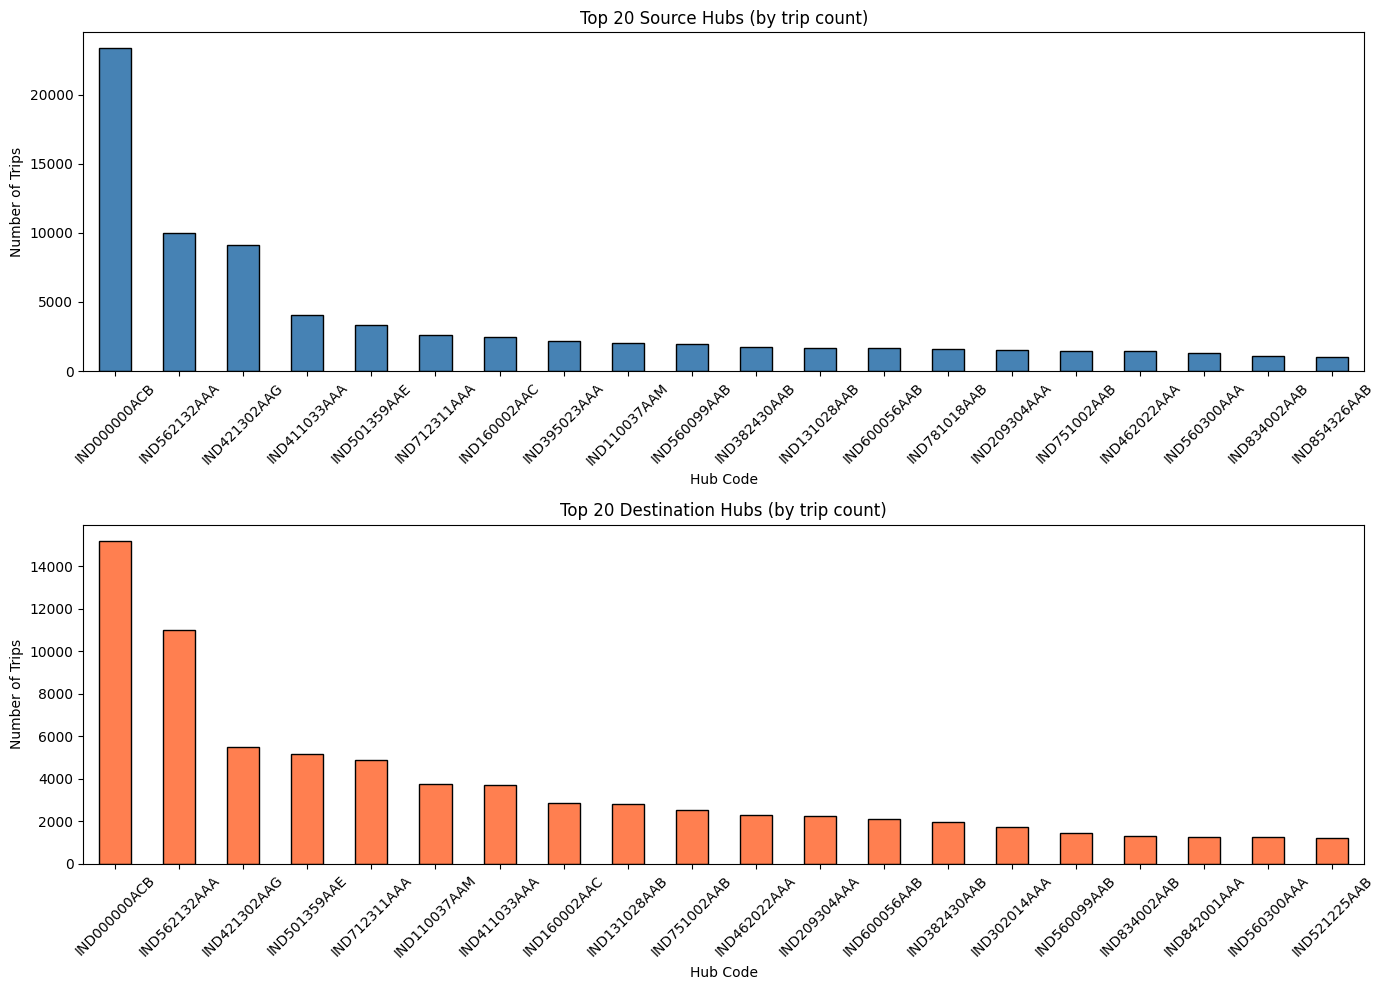


Total unique source hubs: 1508
Total unique destination hubs: 1481


In [9]:
# Top source hubs by number of trips
top_sources = df['source_center'].value_counts().head(20)
top_destinations = df['destination_center'].value_counts().head(20)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

top_sources.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Top 20 Source Hubs (by trip count)')
axes[0].set_xlabel('Hub Code')
axes[0].set_ylabel('Number of Trips')
axes[0].tick_params(axis='x', rotation=45)

top_destinations.plot(kind='bar', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Top 20 Destination Hubs (by trip count)')
axes[1].set_xlabel('Hub Code')
axes[1].set_ylabel('Number of Trips')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../outputs/top_hubs.png')
plt.show()
print(f"\nTotal unique source hubs: {df['source_center'].nunique()}")
print(f"Total unique destination hubs: {df['destination_center'].nunique()}")

Average Delay Factor by Route Type:
route_type
Carting    2.603102
FTL        2.043849
Name: segment_factor, dtype: float64

Correlation between key numeric columns:
                                actual_time  osrm_time  \
actual_time                        1.000000   0.977998   
osrm_time                          0.977998   1.000000   
actual_distance_to_destination     0.978659   0.995872   
segment_factor                     0.017558  -0.033057   
osrm_distance                      0.979399   0.999119   

                                actual_distance_to_destination  \
actual_time                                           0.978659   
osrm_time                                             0.995872   
actual_distance_to_destination                        1.000000   
segment_factor                                       -0.031603   
osrm_distance                                         0.997149   

                                segment_factor  osrm_distance  
actual_time             

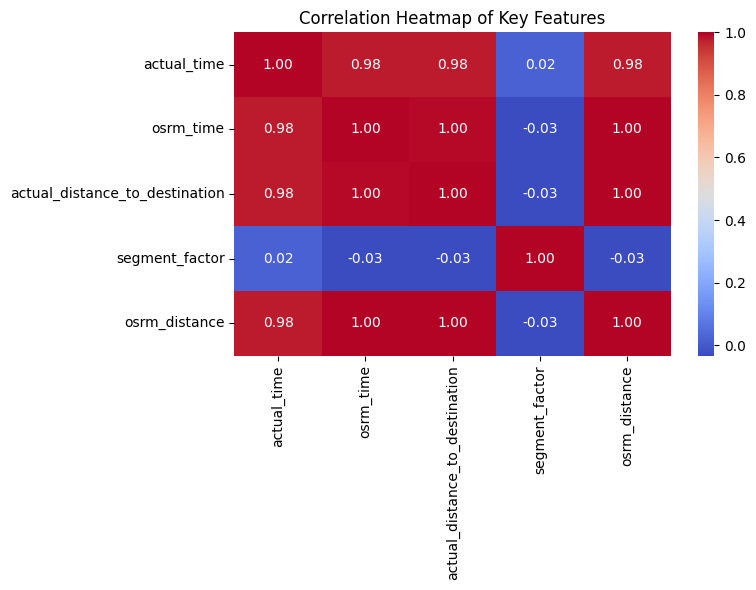

In [10]:
# Average delay factor by route type
print("Average Delay Factor by Route Type:")
print(df.groupby('route_type')['segment_factor'].mean())

print("\nCorrelation between key numeric columns:")
cols = ['actual_time', 'osrm_time', 'actual_distance_to_destination', 
        'segment_factor', 'osrm_distance']
corr = df[cols].corr()
print(corr)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap of Key Features')
plt.tight_layout()
plt.savefig('../outputs/correlation_heatmap.png')
plt.show()